<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_vs_mlp_sp2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Установка библиотек**

In [13]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-5xc8i1qf
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-5xc8i1qf
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
Работает на устройстве: cpu


# **Обучение KAN**

Сеть построенная по уравнению

In [60]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []

for k in [2.0, 4.0, 6.0]:
  for c in [0.1, 0.3, 0.5]:
    for m in [0.5, 1.0, 2.0]:

      for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
        for v0 in [0.0, 0.5, 1.0]:

          sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 10, 100))
          x, v = sol.y
          a_clean = -(k/m)*x - (c/m)*v # истинное ускорение

          for i in range(len(x)):
            all_data.append([c, v[i], k, x[i], m, a_clean[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

X = all_data[:, :5]   # (x, v, k, c, m)
y = all_data[:, 5]    # a

# Разбиение на train/test (исходное)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование только x и v (обучаем scaler на трейне, применяем ко всем)
from sklearn.preprocessing import StandardScaler
scaler_dyn = StandardScaler()
scaler_dyn.fit(X_train[:, :2])
X_train[:, :2] = scaler_dyn.transform(X_train[:, :2])
X_test[:, :2]  = scaler_dyn.transform(X_test[:, :2])

# Подвыборки
n_train = 6000
indices_train = np.random.choice(len(X_train), size=n_train, replace=False)
X_train_sub = X_train[indices_train]
y_train_sub = y_train[indices_train]

n_test = 1500
indices_test = np.random.choice(len(X_test), size=n_test, replace=False)
X_test_sub = X_test[indices_test]
y_test_sub = y_test[indices_test]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")

Всего точек: 40500
train: 6000 примеров, test: 1500 примеров


In [61]:
from kan.compiler import kanpiler
from sympy import symbols, exp, sin, pi
from kan.utils import create_dataset
import torch

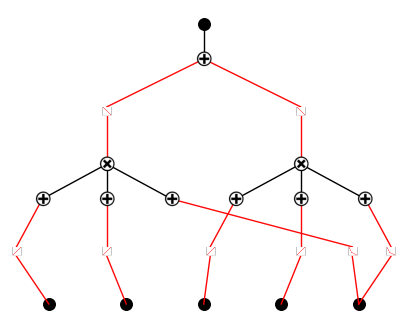

In [70]:
# Определение символьных переменных и формулуы
x, v, k, c, m = symbols('x, v, k, c, m')
expr = -(k/m)*x-(c/m)*v

# Компиляция
model_kan = kanpiler(input_variables=[c, v, k, x, m], expr=expr)

model_kan.get_act(dataset)
model_kan.plot()

| train_loss: 5.84e-03 | test_loss: 5.62e-03 | reg: 0.00e+00 | : 100%|█| 1200/1200 [01:41<00:00, 11.


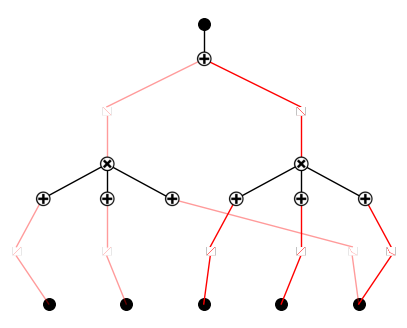

In [71]:
model_kan.fit(dataset, opt="Adam", steps=700, lr=0.01)
model_kan.plot()

In [72]:
lib = ['x']
model_kan.auto_symbolic(lib=lib)
formula = ex_round(model_kan.symbolic_formula()[0][0],4)
print("Символьная формула KAN: ", formula)

skipping (0,0,0) since already symbolic
skipping (0,0,1) since already symbolic
skipping (0,0,2) since already symbolic
skipping (0,0,3) since already symbolic
skipping (0,0,4) since already symbolic
skipping (0,0,5) since already symbolic
skipping (0,1,0) since already symbolic
skipping (0,1,1) since already symbolic
skipping (0,1,2) since already symbolic
skipping (0,1,3) since already symbolic
skipping (0,1,4) since already symbolic
skipping (0,1,5) since already symbolic
skipping (0,2,0) since already symbolic
skipping (0,2,1) since already symbolic
skipping (0,2,2) since already symbolic
skipping (0,2,3) since already symbolic
skipping (0,2,4) since already symbolic
skipping (0,2,5) since already symbolic
skipping (0,3,0) since already symbolic
skipping (0,3,1) since already symbolic
skipping (0,3,2) since already symbolic
skipping (0,3,3) since already symbolic
skipping (0,3,4) since already symbolic
skipping (0,3,5) since already symbolic
skipping (0,4,0) since already symbolic


KAN

In [2]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v
    return [v, a]

all_data = []

for k in [2.0, 4.0, 6.0]:
  for c in [0.1, 0.3, 0.5]:
    for m in [0.5, 1.0, 2.0]:
      for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
        for v0 in [0.0, 0.5, 1.0]:
          sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 10, 100))
          x, v = sol.y
          a_clean = -(k/m)*x - (c/m)*v
          for i in range(len(x)):
            all_data.append([x[i], v[i], k, c, 1/m, a_clean[i]])

all_data = np.array(all_data)

# Исходные столбцы
x = all_data[:, 0]
v = all_data[:, 1]
k = all_data[:, 2]
c = all_data[:, 3]
inv_m = all_data[:, 4]
a = all_data[:, 5]

# Производные признаки
k_over_m = k * inv_m
c_over_m = c * inv_m
k_x_over_m = k * x * inv_m
c_v_over_m = c * v * inv_m

# Формируем массив: первые 5 — исходные, остальные 4 — производные
X_raw = np.column_stack([x, v, k, c, inv_m, k_over_m, c_over_m, k_x_over_m, c_v_over_m])

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(X_raw, a, test_size=0.2, random_state=42)

# Масштабируем ТОЛЬКО исходные 5 признаков (столбцы 0..4)
scaler = StandardScaler()
X_train_scaled_part = scaler.fit_transform(X_train[:, :5])
X_test_scaled_part = scaler.transform(X_test[:, :5])

# Оставшиеся производные признаки оставляем без изменений
X_train_final = np.hstack([X_train_scaled_part, X_train[:, 5:]])
X_test_final = np.hstack([X_test_scaled_part, X_test[:, 5:]])

# Подвыборки
n_train = 10000
idx = np.random.choice(len(X_train_final), n_train, replace=False)
X_train_sub = X_train_final[idx]
y_train_sub = y_train[idx]

n_test = 3000
idx = np.random.choice(len(X_test_final), n_test, replace=False)
X_test_sub = X_test_final[idx]
y_test_sub = y_test[idx]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"Всего точек: {len(all_data)}")
print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")
print(f"Размерность входа: {X_train_t.shape[1]}")

Всего точек: 40500
train: 10000 примеров, test: 3000 примеров
Размерность входа: 9


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 9.57e-02 | test_loss: 1.05e-01 | reg: 1.10e+01 | : 100%|█| 500/500 [00:41<00:00, 11.94


saving model version 0.1


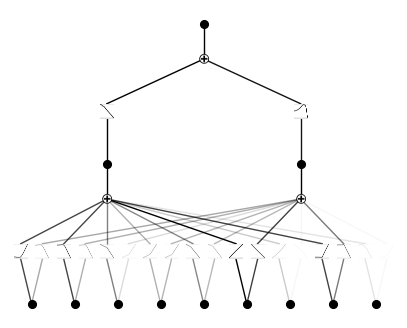

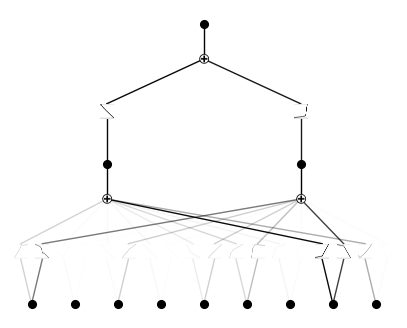

In [3]:
model = KAN(width=[9, 2, 1], grid=3, k=1, seed=42, device=device)
model(dataset['train_input']);
model.plot()

model.fit(dataset, opt="Adam", steps=500, lr=0.01)
model.plot()

| train_loss: 1.35e-03 | test_loss: 3.10e-02 | reg: 1.04e+01 | : 100%|█| 300/300 [02:38<00:00,  1.89


saving model version 0.2


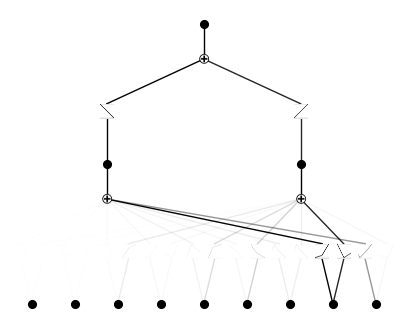

In [4]:
model.fit(dataset, opt="LBFGS", steps=300, lr=0.5, lamb=0.0)
model.plot()

saving model version 0.3


| train_loss: 3.62e-03 | test_loss: 3.11e-02 | reg: 8.67e+00 | : 100%|█| 100/100 [00:39<00:00,  2.54


saving model version 0.4


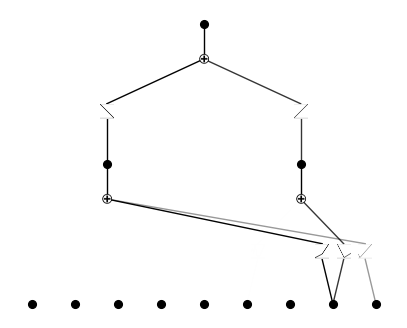

In [6]:
model = model.prune(edge_th=5e-2)
model.fit(dataset, opt="LBFGS", steps=100, update_grid=False)
model.plot()

In [7]:
lib = ['x']
model.auto_symbolic(lib=lib)
formula = ex_round(model.symbolic_formula()[0][0], 4)
print("Символьная формула KAN:", formula)

fixing (0,0,0) with 0
fixing (0,0,1) with 0
fixing (0,1,0) with 0
fixing (0,1,1) with 0
fixing (0,2,0) with 0
fixing (0,2,1) with 0
fixing (0,3,0) with 0
fixing (0,3,1) with 0
fixing (0,4,0) with 0
fixing (0,4,1) with 0
fixing (0,5,0) with 0
fixing (0,5,1) with x, r2=0.0005256594740785658, c=1
fixing (0,6,0) with 0
fixing (0,6,1) with 0
fixing (0,7,0) with x, r2=0.8820962905883789, c=1
fixing (0,7,1) with x, r2=0.31989654898643494, c=1
fixing (0,8,0) with x, r2=0.9834153056144714, c=1
fixing (0,8,1) with 0
fixing (1,0,0) with x, r2=0.9999985098838806, c=1
fixing (1,1,0) with x, r2=0.9999983906745911, c=1
saving model version 0.5


/usr/local/lib/python3.12/dist-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))


Символьная формула KAN: -1.0001*x_8 - 0.9719*x_9 - 0.0007


MultKAN

In [18]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v
    return [v, a]

all_data = []
for k in [2.0, 4.0, 6.0]:
    for c in [0.1, 0.3, 0.5]:
        for m in [0.5, 1.0, 2.0]:
            inv_m = 1.0 / m
            for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
                for v0 in [0.0, 0.5, 1.0]:
                    sol = solve_ivp(rhs, (0, 20), y0=[x0, v0],
                                    t_eval=np.linspace(0, 10, 100))
                    x, v = sol.y
                    a = -(k/m)*x - (c/m)*v
                    for i in range(len(x)):
                        all_data.append([x[i], v[i], k, c, inv_m, a[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

X = all_data[:, :5]   # x, v, k, c, 1/m
y = all_data[:, 5]    # a

# Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабируем только x и v (первые два столбца) – остальные не трогаем
scaler = StandardScaler()
scaler.fit(X_train[:, :2])
X_train[:, :2] = scaler.transform(X_train[:, :2])
X_test[:, :2]  = scaler.transform(X_test[:, :2])

# Небольшая подвыборка для скорости
n_train = 8000
n_test  = 2000
idx_train = np.random.choice(len(X_train), n_train, replace=False)
idx_test  = np.random.choice(len(X_test),  n_test,  replace=False)

X_train_sub = X_train[idx_train]
y_train_sub = y_train[idx_train]
X_test_sub  = X_test[idx_test]
y_test_sub  = y_test[idx_test]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input':  X_test_t,
    'test_label':  y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")
print(f"Размерность входа: {X_train_t.shape[1]}")

Всего точек: 40500
train: 8000 примеров, test: 2000 примеров
Размерность входа: 5


checkpoint directory created: ./model
saving model version 0.0


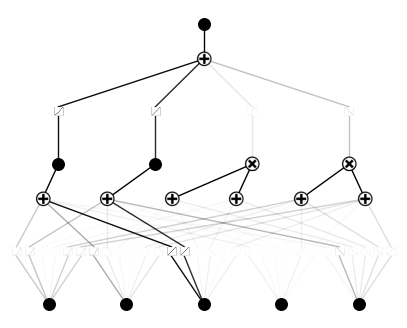

In [20]:
model = KAN(width=[5, [2, 2], 1], grid=5, k=3, seed=42, device=device)

model(dataset['train_input'])
model.plot()

| train_loss: 7.10e-02 | test_loss: 7.81e-02 | reg: 2.05e+01 | : 100%|█| 500/500 [00:52<00:00,  9.62


saving model version 0.1


| train_loss: 6.33e-03 | test_loss: 8.11e-03 | reg: 1.50e+01 | : 100%|█| 500/500 [12:45<00:00,  1.53


saving model version 0.2


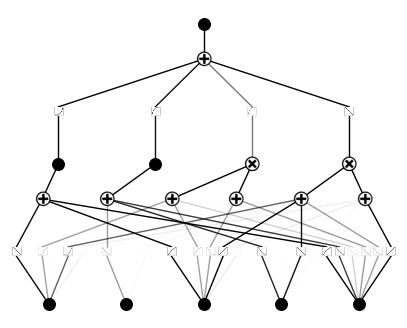

In [21]:
model.fit(dataset, opt="Adam", steps=500, lr=0.01)

model.fit(dataset, opt="LBFGS", steps=500, lr=0.5, lamb=0.0, lamb_entropy=1e-6)   # лёгкая энтропийная регуляризация
model.plot()

saving model version 0.3


| train_loss: 7.81e-03 | test_loss: 9.65e-03 | reg: 2.37e+01 | : 100%|█| 100/100 [02:31<00:00,  1.52


saving model version 0.4


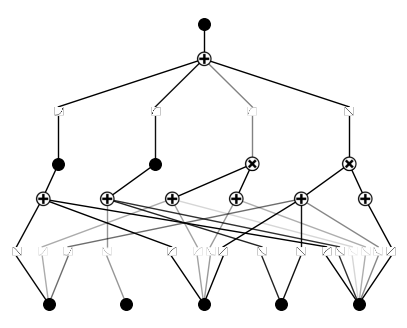

In [22]:
model = model.prune(edge_th=0.05)   # удаляем самые слабые связи
model.fit(dataset, opt="LBFGS", steps=100, update_grid=False, lr=0.2)
model.plot()

In [23]:
lib = ['x']  # только линейные, т.к. произведения уже должны быть внутри
model.auto_symbolic(lib=lib)
formula = ex_round(model.symbolic_formula()[0][0], 4)
print("Символьная формула KAN:", formula)

fixing (0,0,0) with x, r2=0.9975912570953369, c=1
fixing (0,0,1) with 0
fixing (0,0,2) with x, r2=0.9811959266662598, c=1
fixing (0,0,3) with 0
fixing (0,0,4) with x, r2=0.788905143737793, c=1
fixing (0,0,5) with 0
fixing (0,1,0) with 0
fixing (0,1,1) with x, r2=0.9400643706321716, c=1
fixing (0,1,2) with 0
fixing (0,1,3) with 0
fixing (0,1,4) with 0
fixing (0,1,5) with 0
fixing (0,2,0) with x, r2=0.9687916040420532, c=1
fixing (0,2,1) with 0
fixing (0,2,2) with x, r2=0.961158275604248, c=1
fixing (0,2,3) with x, r2=0.8160178661346436, c=1
fixing (0,2,4) with x, r2=0.9989891052246094, c=1
fixing (0,2,5) with 0
fixing (0,3,0) with 0
fixing (0,3,1) with x, r2=0.961471438407898, c=1
fixing (0,3,2) with 0
fixing (0,3,3) with 0
fixing (0,3,4) with x, r2=0.9999701976776123, c=1
fixing (0,3,5) with 0
fixing (0,4,0) with x, r2=0.9634986519813538, c=1
fixing (0,4,1) with x, r2=0.9637579321861267, c=1
fixing (0,4,2) with x, r2=0.922700047492981, c=1
fixing (0,4,3) with x, r2=0.9821088314056396, 

In [26]:
with torch.no_grad():
    pred_test = model(X_test_t).cpu().numpy().flatten()
mse = np.mean((pred_test - y_test_sub)**2)
print(f"\nMSE на тесте: {mse:.6f}")

# Визуальная проверка нескольких примеров
print("\nПримеры предсказаний vs истина:")
for i in np.random.choice(len(X_test_sub), 5, replace=False):
    x_scaled, v_scaled, k_i, c_i, inv_m_i = X_test_sub[i]
    # обратное масштабирование только для x и v
    orig_x = x_scaled * scaler.scale_[0] + scaler.mean_[0]
    orig_v = v_scaled * scaler.scale_[1] + scaler.mean_[1]
    m_i = 1.0 / inv_m_i
    true_a = -(k_i/m_i)*orig_x - (c_i/m_i)*orig_v
    pred_a = pred_test[i]
    print(f"  x={orig_x:.2f}, v={orig_v:.2f}, k={k_i:.1f}, c={c_i:.1f}, m={m_i:.1f}: "
          f"истинное a={true_a:.3f}, предсказанное a={pred_a:.3f}")


MSE на тесте: 2.175365

Примеры предсказаний vs истина:
  x=0.04, v=0.31, k=4.0, c=0.5, m=0.5: истинное a=-0.668, предсказанное a=0.157
  x=0.41, v=-0.06, k=2.0, c=0.5, m=2.0: истинное a=-0.395, предсказанное a=-2.841
  x=-0.02, v=-0.01, k=4.0, c=0.5, m=0.5: истинное a=0.164, предсказанное a=0.552
  x=0.00, v=0.00, k=2.0, c=0.3, m=1.0: истинное a=-0.000, предсказанное a=-0.166
  x=0.06, v=-0.32, k=6.0, c=0.5, m=2.0: истинное a=-0.116, предсказанное a=0.850
